In [2]:
import pandas as pd

benin = pd.read_csv('../notebooks/data/benin_clean.csv')
sierra_leone = pd.read_csv('../notebooks/data/sierraleone_clean.csv')

In [4]:
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'


df = pd.concat([benin, sierra_leone, ], ignore_index=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12084\3715718993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df, palette='Set2')


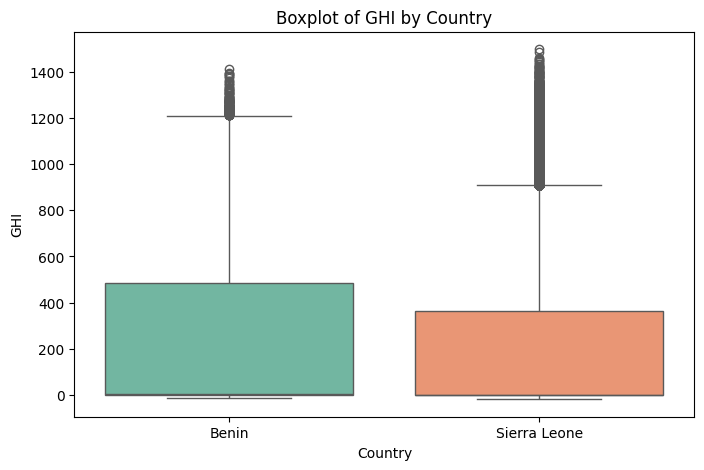

C:\Users\HP\AppData\Local\Temp\ipykernel_12084\3715718993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df, palette='Set2')


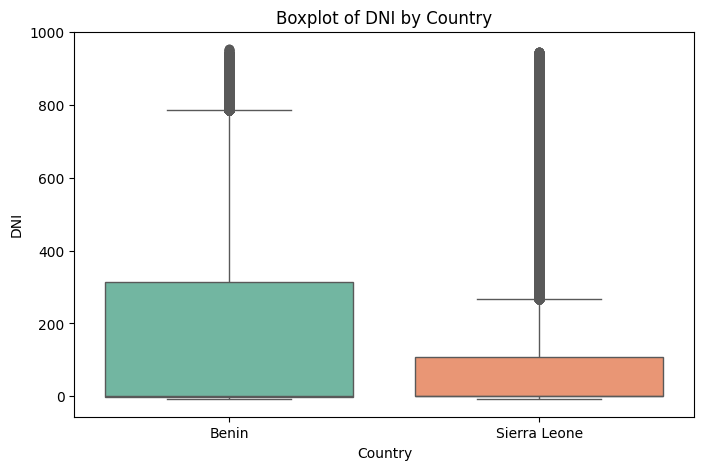

C:\Users\HP\AppData\Local\Temp\ipykernel_12084\3715718993.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df, palette='Set2')


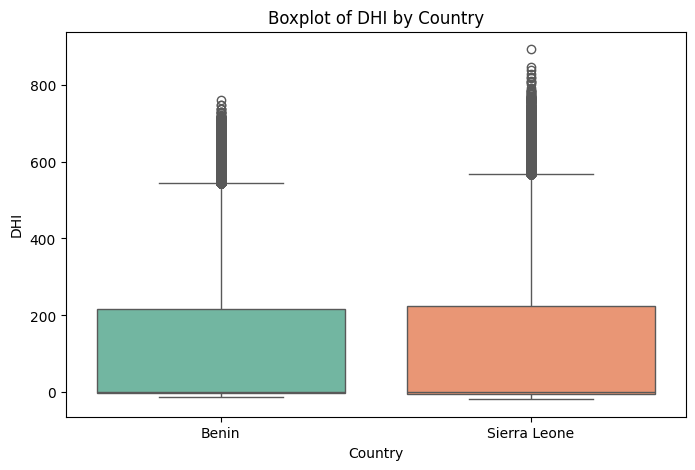

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ['GHI', 'DNI', 'DHI']

for metric in metrics:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Country', y=metric, data=df, palette='Set2')
    plt.title(f'Boxplot of {metric} by Country')
    plt.show()

In [6]:
# Summary Table: mean, median, std of GHI, DNI, DHI by Country
summary = df.groupby('Country')[metrics].agg(['mean', 'median', 'std']).round(2)
summary

GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         240.56    1.8  331.13  167.19   -0.1  261.71  115.36    1.6   
Sierra Leone  201.96    0.3  298.50  116.38   -0.1  218.65  113.72   -0.1   

                      
                 std  
Country               
Benin         158.69  
Sierra Leone  158.95

In [8]:
# Statistical Testing: One-way ANOVA or Kruskal–Wallis on GHI
from scipy.stats import f_oneway, kruskal

ghi_benin = benin['GHI'].dropna()
ghi_sierra = sierra_leone['GHI'].dropna()


# Run ANOVA
anova_res = f_oneway(ghi_benin, ghi_sierra, )

# If non-normal, use Kruskal-Wallis
kruskal_res = kruskal(ghi_benin, ghi_sierra, )

print(f"ANOVA p-value: {anova_res.pvalue:.4f}")
print(f"Kruskal-Wallis p-value: {kruskal_res.pvalue:.4f}")

ANOVA p-value: 0.0000
Kruskal-Wallis p-value: 0.0000


C:\Users\HP\AppData\Local\Temp\ipykernel_12084\3434622465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette='viridis')


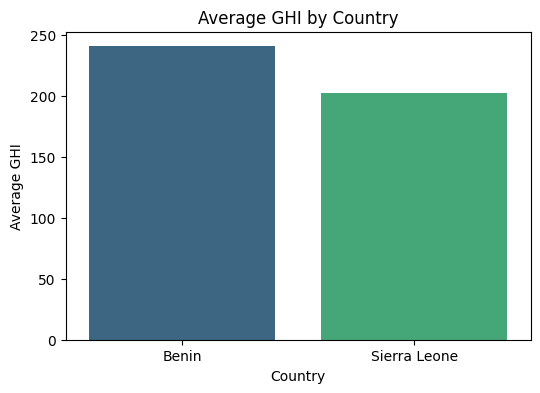

In [9]:
# Bar Chart Ranking Countries by Average GHI
avg_ghi = df.groupby('Country')['GHI'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette='viridis')
plt.ylabel('Average GHI')
plt.title('Average GHI by Country')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# # Correlation Matrix
correlation_matrix = combined_data[['GHI', 'DNI', 'DHI']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

c:\Users\HP\solar-challenge-week1\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


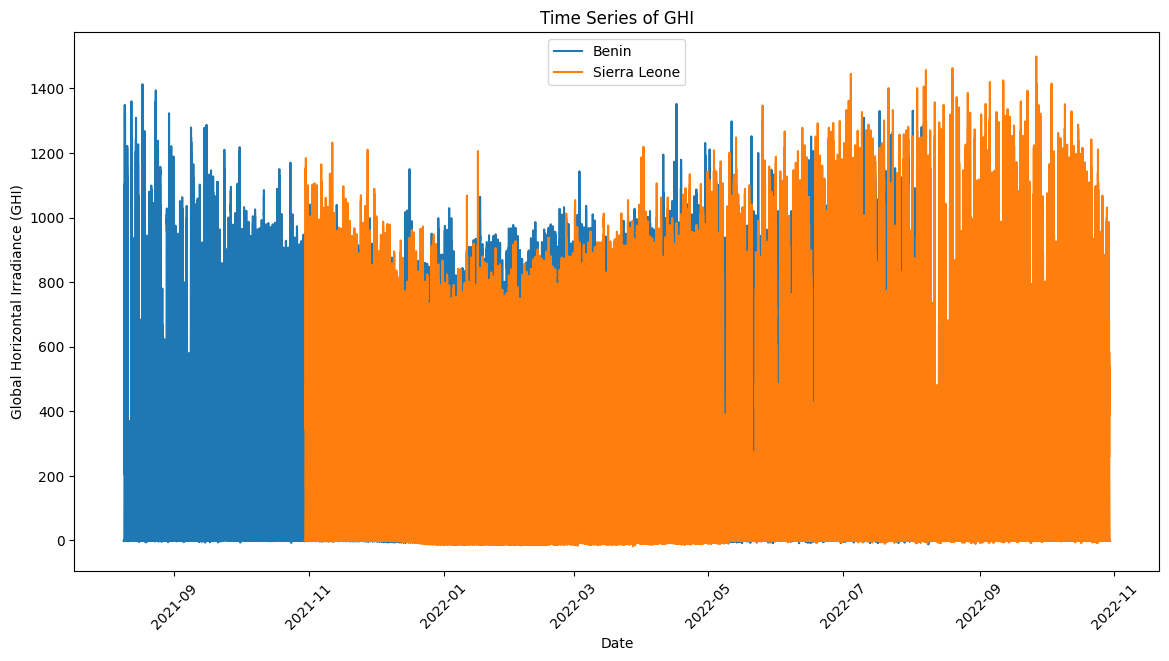

In [18]:
import matplotlib.pyplot as plt

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
plt.figure(figsize=(14, 7))
for country in ['Benin', 'Sierra Leone', ]:
    country_data = df[df['Country'] == country]
    plt.plot(country_data['Timestamp'], country_data['GHI'], label=country)

plt.xlabel('Date')
plt.ylabel('Global Horizontal Irradiance (GHI)')
plt.title('Time Series of GHI')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [19]:
summary_stats = df.groupby('Country')[['GHI', 'DNI', 'DHI']].describe()
print(summary_stats)

                   GHI                                                         \
                 count        mean         std   min  25%  50%    75%     max   
Country                                                                         
Benin         525600.0  240.559452  331.131327 -12.9 -2.0  1.8  483.4  1413.0   
Sierra Leone  525600.0  201.957515  298.495150 -19.5 -2.8  0.3  362.4  1499.0   

                   DNI              ...                     DHI              \
                 count        mean  ...    75%    max     count        mean   
Country                             ...                                       
Benin         525600.0  167.187516  ...  314.2  952.3  525600.0  115.358961   
Sierra Leone  525600.0  116.376337  ...  107.0  946.0  525600.0  113.720571   

                                                        
                     std   min  25%  50%    75%    max  
Country                                                 
Benin         158.691074 -1